# Video Emotion Recognition Model Training Pipeline

## Configuration

### Imports

**Note:** For RetinaFace with TensorFlow 2.16+: **Restart kernel** and **Run All** from the top so `TF_USE_LEGACY_KERAS` takes effect before TensorFlow loads.

In [1]:
import os
# Must be set BEFORE any TensorFlow import - fixes KerasTensor compatibility with RetinaFace on TF 2.16+
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import cv2
import numpy as np
# Import TensorFlow FIRST so it loads with legacy Keras, then RetinaFace will use it
import tensorflow as tf
from retinaface import RetinaFace
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

2026-02-02 04:25:45.064271: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 04:25:45.847145: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import sys
print('Python executable:', sys.executable)

Python executable: /home/yousef/Scenolytics/tf-gpu/bin/python


In [3]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # Required for RetinaFace with TF 2.16+
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Global Variables

In [4]:
# Paths
VIDEOS_DIR = os.path.abspath('./../Datasets/Video')

# Use a separate folder so you don't mix the full dataset with the actor subset
ACTOR_START_INDEX = 23  # Start from this actor (0 = first 24, 24 = actors 25-48)
ACTOR_LIMIT = 24  # Number of actors to use
PREPROCESSED_DIR = f'./preprocessed_data_actors_{ACTOR_START_INDEX+1}_to_{ACTOR_START_INDEX+ACTOR_LIMIT}'

MODEL_SAVE_PATH = './models/best_video_emotion_model.h5'

# Emotion mapping
EMOTIONS = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}
EMOTION_TO_IDX = {emotion: idx for idx, emotion in enumerate(EMOTIONS.values())}
NUM_EMOTIONS_CLASSES = len(EMOTIONS)

# Video preprocessing
FRAMES_PER_VIDEO = 10  # Reduced from 20 for faster processing and less overfitting
IMG_SIZE = 160  # Reduced from 224 for faster processing
FRAME_RATE = 10

# Model architecture
LSTM_UNITS = 128  # Increased for better capacity (was 64)
LSTM_LAYERS = 2  # Back to 2 layers as requested
DROPOUT_RATE = 0.35  # Reduced from 0.5 to reduce underfitting

# Training
BATCH_SIZE = 16  # Increased from 8 for faster training
EPOCHS = 50  # Reduced from 80
LEARNING_RATE = 1e-4  # Increased from 5e-5 for faster convergence
PATIENCE = 15  # Reduced from 25

## Pre-Processing

### Face detection

In [5]:
def detect_and_crop_face(frame):
    """Detect and crop face from frame using RetinaFace"""
    RGB_Frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    Faces = RetinaFace.detect_faces(RGB_Frame)
    
    if isinstance(Faces, dict) and len(Faces) > 0:
        First_Face = next(iter(Faces.values()))
        Facial_Area = First_Face["facial_area"]
        x1, y1, x2, y2 = Facial_Area
        # Add padding
        padding = 20
        x1 = max(0, x1 - padding)
        y1 = max(0, y1 - padding)
        x2 = min(frame.shape[1], x2 + padding)
        y2 = min(frame.shape[0], y2 + padding)
        
        face = frame[y1:y2, x1:x2]
        return face
    
    return frame

### Frames Extraction

In [6]:
def extract_frames_from_video(video_path, num_frames=16, target_size=(224, 224)):
    """Extract evenly spaced frames from video"""
    Cap = cv2.VideoCapture(video_path)
    Total_Frames = int(Cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if Total_Frames < num_frames:
        Frame_Indices = np.linspace(0, Total_Frames - 1, num_frames, dtype=int)
    else:
        Frame_Indices = np.linspace(0, Total_Frames - 1, num_frames, dtype=int)
    
    Frames = []
    for i in Frame_Indices:
        Cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        IsReturned, Frame = Cap.read()
        
        if IsReturned:
            Frame = detect_and_crop_face(Frame)
            Frame = cv2.resize(Frame, target_size)
            Frame = cv2.cvtColor(Frame, cv2.COLOR_BGR2RGB)
            Frames.append(Frame)
        else:
            if Frames:
                Frames.append(Frames[-1])
            else:
                Frames.append(np.zeros((target_size[0], target_size[1], 3)))
    
    Cap.release()
    return np.array(Frames)

### Preprocessing & Saving Preproccesed Data

In [7]:
def preprocess_and_save_dataset():
    """
    Preprocess all videos and save to disk
    This only needs to be run ONCE
    """
    print("="*80)
    print("PREPROCESSING DATASET")
    print("="*80)
    
    # Create preprocessed directory
    Path(PREPROCESSED_DIR).mkdir(parents=True, exist_ok=True)
    
    metadata = []
    video_count = 0

    all_actors = [a for a in sorted(os.listdir(VIDEOS_DIR)) if os.path.isdir(os.path.join(VIDEOS_DIR, a))]
    start = ACTOR_START_INDEX if 'ACTOR_START_INDEX' in globals() else 0
    limit = ACTOR_LIMIT if 'ACTOR_LIMIT' in globals() else len(all_actors)
    selected_actors = all_actors[start:start + limit]

    print(f"Using actors {start+1} to {start+len(selected_actors)} (indices {start}:{start+len(selected_actors)}): {selected_actors[:3]} ... {selected_actors[-3:]}")
    
    for Actor in selected_actors:
        Actor_Path = os.path.join(VIDEOS_DIR, Actor)
        
        if not os.path.isdir(Actor_Path):
            continue
        
        Video_Files = [f for f in os.listdir(Actor_Path) 
                      if f.endswith('.mp4')]
        
        print(f"\nProcessing {len(Video_Files)} videos from {Actor}")
        
        for idx, Video_File in enumerate(Video_Files):
            Video_Path = os.path.join(Actor_Path, Video_File)
            
            try:
                # Extract emotion from filename
                # Format: Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor
                parts = Video_File.split('-')
                
                if len(parts) < 3:
                    print(f"  Skipping {Video_File}: Invalid filename format")
                    continue
                
                emotion_code = parts[2]
                emotion_name = EMOTIONS.get(emotion_code)
                
                if emotion_name is None:
                    print(f"  Skipping {Video_File}: Unknown emotion code {emotion_code}")
                    continue
                
                emotion_idx = EMOTION_TO_IDX[emotion_name]
                
                # Extract and process frames
                frames = extract_frames_from_video(
                    Video_Path,
                    num_frames=FRAMES_PER_VIDEO,
                    target_size=(IMG_SIZE, IMG_SIZE)
                )
                
                # Normalize
                frames = frames.astype(np.float32) / 255.0
                
                # Save preprocessed frames
                save_path = os.path.join(PREPROCESSED_DIR, f"video_{video_count:05d}.npy")
                np.save(save_path, frames)
                
                # Store metadata
                metadata.append((save_path, emotion_idx, emotion_name))
                video_count += 1
                
                if (idx + 1) % 10 == 0:
                    print(f"  Processed {idx + 1}/{len(Video_Files)} videos")
                
            except Exception as e:
                print(f"  Error processing {Video_File}: {e}")
                continue
    
    # Save metadata
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    
    print(f"\n{'='*80}")
    print(f"PREPROCESSING COMPLETE!")
    print(f"Total videos processed: {video_count}")
    print(f"Metadata saved to: {metadata_path}")
    
    # Print emotion distribution
    from collections import Counter
    emotion_labels = [item[1] for item in metadata]
    emotion_counts = Counter(emotion_labels)
    print(f"\nEmotion distribution:")
    emotion_names = list(EMOTIONS.values())
    for label, count in sorted(emotion_counts.items()):
        print(f"  {emotion_names[label]}: {count} videos")
    
    print(f"{'='*80}\n")
    
    return metadata

In [8]:
# Load preprocessed metadata (paths + labels) for training/evaluation
import os
import pickle


def load_preprocessed_metadata():
    """Load preprocessed metadata and return (file_paths, labels).

    Expects PREPROCESSED_DIR/metadata.pkl created by preprocess_and_save_dataset().
    Metadata items are stored like: (npy_path, emotion_idx, emotion_name).
    """
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata.pkl')

    if not os.path.exists(metadata_path):
        raise FileNotFoundError(
            f"Preprocessed metadata not found at {metadata_path}. "
            "Run preprocess_and_save_dataset() first."
        )

    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)

    # Support both 2-tuple and 3-tuple formats
    file_paths = [item[0] for item in metadata]
    labels = [item[1] for item in metadata]

    return file_paths, labels


## Data Augmentation & Batch Processing

In [9]:
def augment_frame(frame):
    """Apply random augmentations to frame"""
    # Random horizontal flip
    if np.random.random() > 0.5:
        frame = cv2.flip(frame, 1)
    
    # Random brightness adjustment
    brightness_factor = np.random.uniform(0.6, 1.4)  # Wider range
    frame = np.clip(frame * brightness_factor, 0, 1)
    
    # Random contrast adjustment
    contrast_factor = np.random.uniform(0.7, 1.3)  # Wider range
    mean = frame.mean()
    frame = np.clip((frame - mean) * contrast_factor + mean, 0, 1)
    
    # Random saturation adjustment
    hsv = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
    saturation_factor = np.random.uniform(0.8, 1.2)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * saturation_factor, 0, 1)
    frame = cv2.cvtColor((hsv * 255).astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
    
    # Small random rotation (-20 to +20 degrees)
    angle = np.random.uniform(-20, 20)
    h, w = frame.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    frame = cv2.warpAffine(frame, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    # Random zoom (0.9 to 1.1)
    zoom_factor = np.random.uniform(0.9, 1.1)
    h, w = frame.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    frame = cv2.resize(frame, (new_w, new_h))
    if zoom_factor > 1:
        # Crop center
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        frame = frame[start_h:start_h+h, start_w:start_w+w]
    else:
        # Pad
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        frame = cv2.copyMakeBorder(frame, pad_h, h - new_h - pad_h, pad_w, w - new_w - pad_w, cv2.BORDER_REFLECT)
    
    return frame

## Model Building & Training

### Building

Architecture: <br>
    1. ResNet50 (pre-trained) extracts spatial features from each frame <br>
    2. Bi-LSTM processes temporal sequence <br>
    3. Attention mechanism focuses on important frames <br>
    4. Classification head <br>

In [10]:
def build_model():
    """Build CNN-LSTM model with attention"""
    print("Building model...")
    
    # Keep everything in tf.keras to avoid mixing backends
    tf.keras.backend.clear_session()
    
    Model_Input_Layer = layers.Input(shape=(FRAMES_PER_VIDEO, IMG_SIZE, IMG_SIZE, 3))

    Base_CNN = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )
    
    for Layer in Base_CNN.layers[:-10]:  # Freeze more layers (was -20)
        Layer.trainable = False
    
    CNN_Features = layers.TimeDistributed(Base_CNN)(Model_Input_Layer)
    CNN_Features = layers.Dropout(DROPOUT_RATE)(CNN_Features)
    
    LSTM_Out = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE,
                   recurrent_dropout=DROPOUT_RATE,
                   kernel_regularizer=regularizers.l2(0.001))
    )(CNN_Features)
    
    LSTM_Out = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE,
                   recurrent_dropout=DROPOUT_RATE,
                   kernel_regularizer=regularizers.l2(0.001))
    )(LSTM_Out)
    
    # Attention Mechanism
    Attention_Layer = layers.Dense(1, activation='tanh')(LSTM_Out)
    Attention_Layer = layers.Flatten()(Attention_Layer)
    Attention_Layer = layers.Activation('softmax')(Attention_Layer)
    Attention_Layer = layers.RepeatVector(2 * LSTM_UNITS)(Attention_Layer)
    Attention_Layer = layers.Permute([2, 1])(Attention_Layer)
    
    attended = layers.Multiply()([LSTM_Out, Attention_Layer])

    # Reduce over time dimension (tf.keras only)
    attended = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(attended)
    
    # Classification Head
    x = layers.Dense(256, activation='relu',  # Reduced from 512
                    kernel_regularizer=regularizers.l2(0.001))(attended)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    
    x = layers.Dense(128, activation='relu',  # Reduced from 256
                    kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    
    Model_Output_Layer = layers.Dense(NUM_EMOTIONS_CLASSES, activation='softmax')(x)
    
    Model = tf.keras.Model(
        inputs=Model_Input_Layer,
        outputs=Model_Output_Layer,
        name='Video_Emotion_Recognition',
    )
    Model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            'accuracy',
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy'),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top_3_accuracy')  # Added top-3
        ]
    )
    
    return Model

### Training

In [11]:
# Data generator (loads preprocessed .npy frame sequences)
import numpy as np
import tensorflow as tf


class VideoDataGenerator(tf.keras.utils.Sequence):
    """Keras Sequence for video emotion data stored as .npy arrays.

    Each .npy is expected to be shape: (FRAMES_PER_VIDEO, IMG_SIZE, IMG_SIZE, 3)
    and already normalized to [0, 1] (as saved by preprocess_and_save_dataset()).
    """

    def __init__(self, file_paths, labels, batch_size=16, shuffle=True, augment=False):
        self.file_paths = list(file_paths)
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_paths = [self.file_paths[i] for i in batch_indices]
        batch_labels = self.labels[batch_indices]

        # ImageNet mean/std for ResNet50 pretrained backbone
        IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        batch_videos = []
        for path in batch_paths:
            frames = np.load(path).astype(np.float32)
            if self.augment and 'augment_frame' in globals():
                frames = np.array([augment_frame(frame) for frame in frames])
            # ResNet50 expects ImageNet normalization
            frames = (frames - IMAGENET_MEAN) / IMAGENET_STD
            batch_videos.append(frames)

        return np.array(batch_videos), batch_labels

    def on_epoch_end(self):
        self.indices = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)


In [12]:
def train_model():
    """Train the model using batch generators"""
    print("="*80)
    print("LOADING PREPROCESSED DATA")
    print("="*80)
    
    # Load metadata
    file_paths, labels = load_preprocessed_metadata()
    print(f"Loaded {len(file_paths)} preprocessed videos")
    
    # Split data
    file_paths_train, file_paths_temp, labels_train, labels_temp = train_test_split(
        file_paths, labels, test_size=0.25, random_state=42, stratify=labels
    )
    file_paths_val, file_paths_test, labels_val, labels_test = train_test_split(
        file_paths_temp, labels_temp, test_size=0.5, random_state=42, stratify=labels_temp
    )
    
    print(f"\nDataset split:")
    print(f"  Train: {len(file_paths_train)} videos")
    print(f"  Validation: {len(file_paths_val)} videos")
    print(f"  Test: {len(file_paths_test)} videos")
    
    # Compute class weights
    Class_Weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels_train),
        y=labels_train
    )
    Class_Weights = dict(enumerate(Class_Weights))
    
    # Create data generators
    train_gen = VideoDataGenerator(file_paths_train, labels_train, 
                                   batch_size=BATCH_SIZE, shuffle=True, augment=True)
    val_gen = VideoDataGenerator(file_paths_val, labels_val, 
                                 batch_size=BATCH_SIZE, shuffle=False)
    test_gen = VideoDataGenerator(file_paths_test, labels_test, 
                                  batch_size=BATCH_SIZE, shuffle=False)
    
    # Build model
    model = build_model()
    print("\n" + "="*80)
    print("MODEL ARCHITECTURE")
    print("="*80)
    model.summary()
    
    # Callbacks
    Path('./models').mkdir(exist_ok=True)
    print(f"\nEarlyStopping patience: {PATIENCE} epochs (will wait {PATIENCE} epochs without improvement before stopping)")
    print(f"ReduceLROnPlateau patience: 5 epochs (reduces learning rate, does NOT stop training)\n")
    callbacks = [
        ModelCheckpoint(
            MODEL_SAVE_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,  # Waits 15 epochs without improvement before stopping
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,  # This only reduces learning rate, NOT stopping training
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    # Train
    print("\n" + "="*80)
    print("TRAINING")
    print("="*80)
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=Class_Weights,
        verbose=1
    )
    
    return model, history, test_gen, labels_test


## Evaluation & Visualization

In [13]:
def evaluate_model(model, test_gen, labels_test):
    """Evaluate model on test set"""
    print("\n" + "="*80)
    print("EVALUATION")
    print("="*80)
    
    # Predictions
    predictions = model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Get unique classes present in test set
    unique_labels = np.unique(labels_test)
    emotion_names = list(EMOTIONS.values())
    present_emotion_names = [emotion_names[i] for i in unique_labels]
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(labels_test, predicted_classes, 
                               labels=unique_labels,
                               target_names=present_emotion_names))
    
    # Confusion matrix
    cm = confusion_matrix(labels_test, predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_emotion_names,
                yticklabels=present_emotion_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('./models/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-Class Accuracy:")
    for i, emotion_idx in enumerate(unique_labels):
        emotion = emotion_names[emotion_idx]
        print(f"  {emotion}: {class_accuracy[i]:.2%}")


def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('./models/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

## Main Execution

Checking GPU availability...
Found 1 GPU(s):
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ GPU configured for training
No preprocessed data found. Starting preprocessing...
PREPROCESSING DATASET
Using actors 24 to 47 (indices 23:47): ['Actor_25', 'Actor_26', 'Actor_27'] ... ['Actor_46', 'Actor_47', 'Actor_48']

Processing 120 videos from Actor_25
  Processed 10/120 videos
  Processed 20/120 videos
  Processed 30/120 videos
  Processed 40/120 videos
  Processed 50/120 videos
  Processed 60/120 videos
  Processed 70/120 videos
  Processed 80/120 videos
  Processed 90/120 videos
  Processed 100/120 videos
  Processed 110/120 videos
  Processed 120/120 videos

Processing 120 videos from Actor_26
  Processed 10/120 videos
  Processed 20/120 videos
  Processed 30/120 videos
  Processed 40/120 videos
  Processed 50/120 videos
  Processed 60/120 videos
  Processed 70/120 videos
  Processed 80/120 videos
  Processed 90/120 videos
  Processed 100/120 videos
  Processed 1

2026-01-30 17:30:12.962267: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f8fcf9d0e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 17:30:12.963320: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-01-30 17:30:13.026928: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769787013.530011    5234 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


135/135 [==============================] - ETA: 0s - loss: 5.6433 - accuracy: 0.1478 - top_2_accuracy: 0.2919 - top_3_accuracy: 0.4226
Epoch 1: val_accuracy improved from -inf to 0.13333, saving model to ./models/best_video_emotion_model.h5
135/135 [==============================] - 182s 1s/step - loss: 5.6433 - accuracy: 0.1478 - top_2_accuracy: 0.2919 - top_3_accuracy: 0.4226 - val_loss: 4.8961 - val_accuracy: 0.1333 - val_top_2_accuracy: 0.3694 - val_top_3_accuracy: 0.5389 - lr: 1.0000e-04
Epoch 2/50
135/135 [==============================] - ETA: 0s - loss: 5.2774 - accuracy: 0.2025 - top_2_accuracy: 0.3638 - top_3_accuracy: 0.4977
Epoch 2: val_accuracy improved from 0.13333 to 0.22778, saving model to ./models/best_video_emotion_model.h5
135/135 [==============================] - 142s 1s/step - loss: 5.2774 - accuracy: 0.2025 - top_2_accuracy: 0.3638 - top_3_accuracy: 0.4977 - val_loss: 4.8038 - val_accuracy: 0.2278 - val_top_2_accuracy: 0.4111 - val_top_3_accuracy: 0.5556 - lr: 1

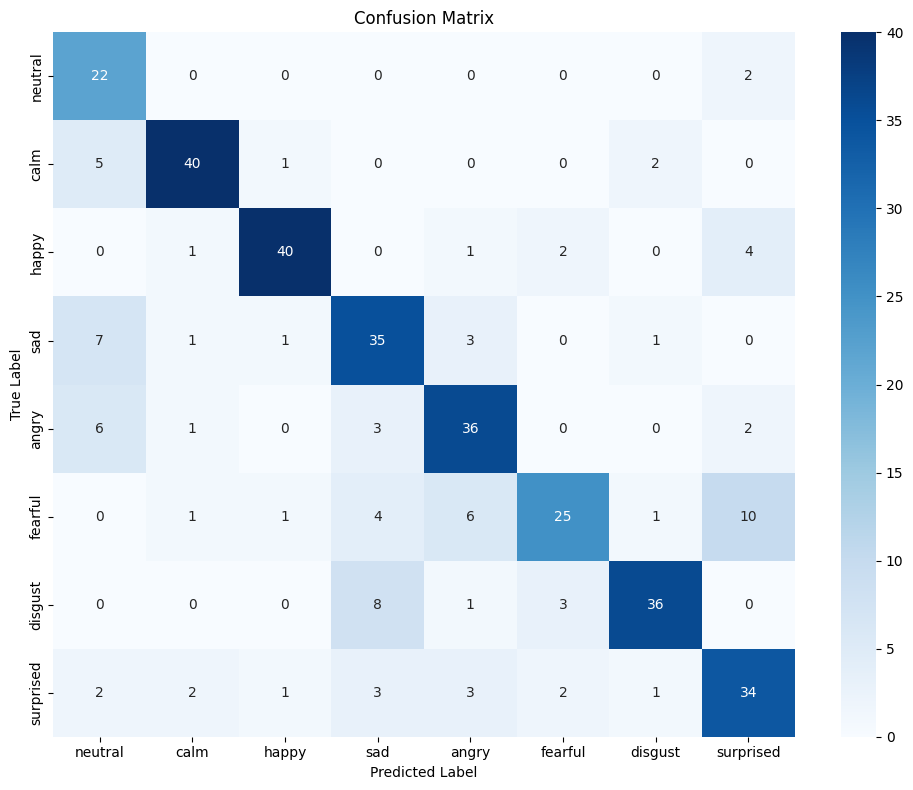


Per-Class Accuracy:
  neutral: 91.67%
  calm: 83.33%
  happy: 83.33%
  sad: 72.92%
  angry: 75.00%
  fearful: 52.08%
  disgust: 75.00%
  surprised: 70.83%


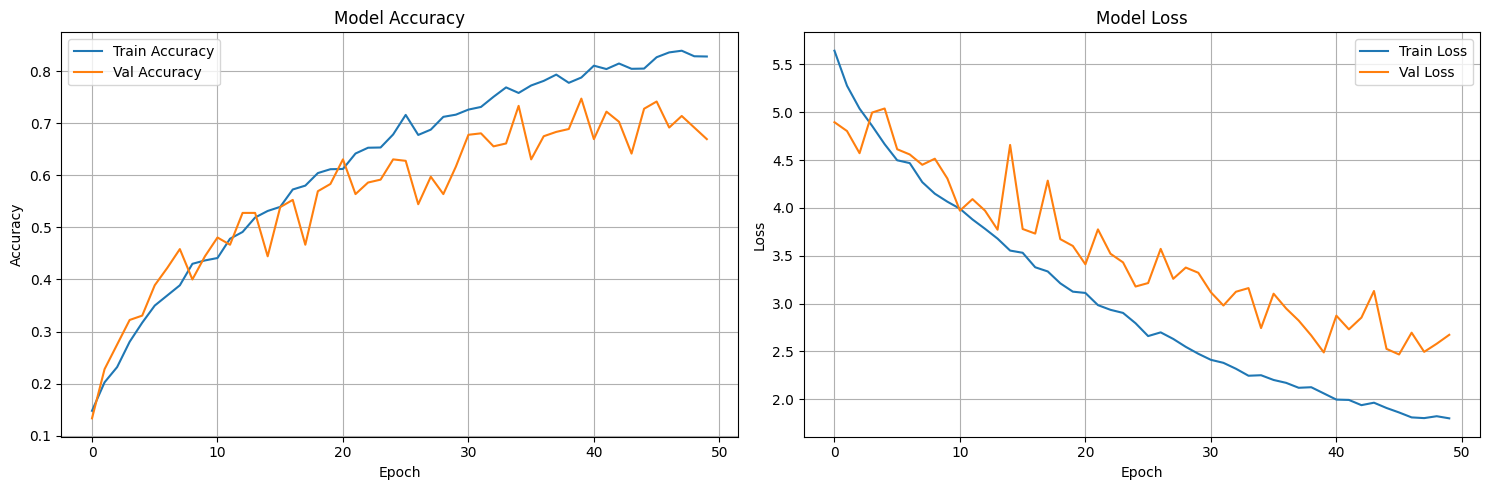


COMPLETE!


In [ ]:
# Clear any cached models
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/wsl/lib:/usr/local/cuda-12.3/targets/x86_64-linux/lib:' + os.environ.get('LD_LIBRARY_PATH', '')
import tensorflow as tf
tf.keras.backend.clear_session()

# Force garbage collection
import gc
gc.collect()

# GPU Configuration
print("Checking GPU availability...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu}")
    
    # Enable memory growth to avoid allocating all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    
    # Set GPU as default device
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("✅ GPU configured for training")
else:
    print("❌ No GPU found! Training will be very slow on CPU.")
    print("Make sure TensorFlow-GPU is installed and GPU drivers are working.")

if __name__ == "__main__":
    # Step 1: Preprocess (run only once)
    if not os.path.exists(os.path.join(PREPROCESSED_DIR, 'metadata.pkl')):
        print("No preprocessed data found. Starting preprocessing...")
        preprocess_and_save_dataset()
    else:
        print("Preprocessed data found. Skipping preprocessing.")
        print("(Delete ./preprocessed_data to reprocess)\n")
    
    # Step 2: Train model
    model, history, test_gen, labels_test = train_model()
    
    # Step 3: Evaluate
    evaluate_model(model, test_gen, labels_test)
    plot_training_history(history)
    
    print("\n" + "="*80)
    print("COMPLETE!")
    print("="*80)

## Data Balance Checking

DATA BALANCE ANALYSIS

📊 Total videos: 2878
📊 Number of emotion classes: 8

------------------------------------------------------------
Emotion         Count      Percentage   Balance
------------------------------------------------------------
neutral         192          6.67%      ⚠️  Under-represented
calm            384         13.34%      ✓ Balanced
happy           384         13.34%      ✓ Balanced
sad             384         13.34%      ✓ Balanced
angry           383         13.31%      ✓ Balanced
fearful         384         13.34%      ✓ Balanced
disgust         383         13.31%      ✓ Balanced
surprised       384         13.34%      ✓ Balanced
------------------------------------------------------------

📈 Statistical Summary:
   Mean samples per class: 359.75
   Std deviation: 63.40
   Min samples: 192
   Max samples: 384
   Imbalance ratio (max/min): 2.00

💡 Interpretation:
   ⚠️  Dataset is MODERATELY IMBALANCED (1.5 < ratio ≤ 3.0)
   → Using class weights (already impl

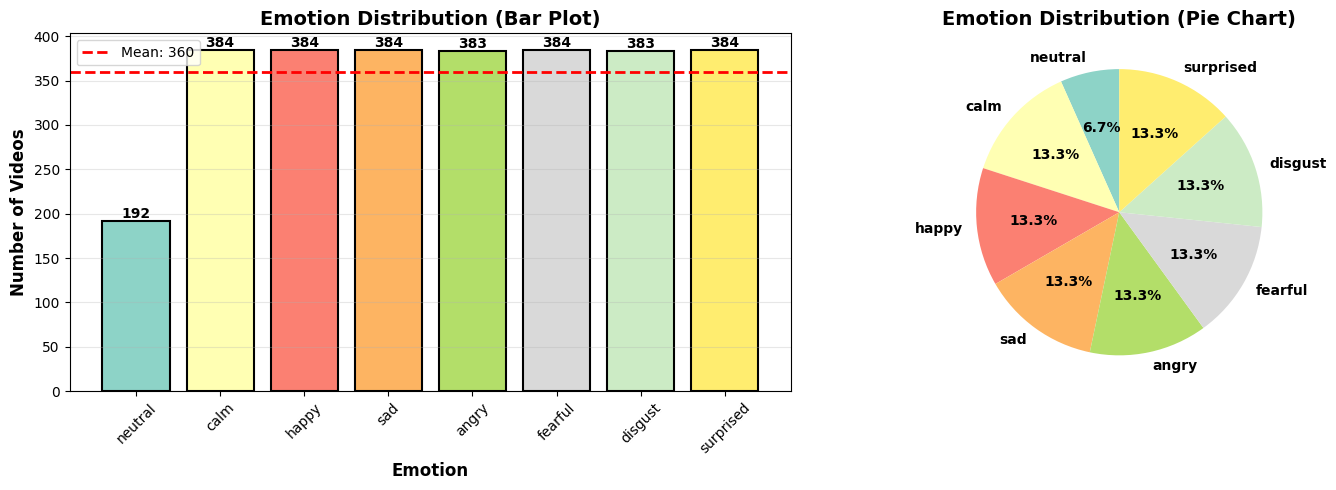

In [17]:
def check_data_balance(show_plot=True):
    """
    Check if the dataset is balanced across emotion classes
    """
    import pickle
    from collections import Counter
    import matplotlib.pyplot as plt
    import numpy as np
    
    print("="*80)
    print("DATA BALANCE ANALYSIS")
    print("="*80)
    
    # Load metadata
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata.pkl')
    
    if not os.path.exists(metadata_path):
        print("❌ No preprocessed data found. Run preprocessing first!")
        return
    
    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)
    
    # Extract labels
    labels = [item[1] for item in metadata]
    emotion_names_list = list(EMOTIONS.values())
    
    # Count emotions
    emotion_counts = Counter(labels)
    total_videos = len(labels)
    
    print(f"\n📊 Total videos: {total_videos}")
    print(f"📊 Number of emotion classes: {len(emotion_counts)}")
    print("\n" + "-"*60)
    print(f"{'Emotion':<15} {'Count':<10} {'Percentage':<12} {'Balance'}")
    print("-"*60)
    
    # Calculate statistics
    counts = []
    for label in sorted(emotion_counts.keys()):
        emotion = emotion_names_list[label]
        count = emotion_counts[label]
        percentage = (count / total_videos) * 100
        counts.append(count)
        
        # Determine balance status
        if percentage > 15:  # More than 15% for 8 classes
            balance = "✅ Over-represented"
        elif percentage < 10:  # Less than 10% for 8 classes
            balance = "⚠️  Under-represented"
        else:
            balance = "✓ Balanced"
        
        print(f"{emotion:<15} {count:<10} {percentage:>6.2f}%      {balance}")
    
    print("-"*60)
    
    # Statistical analysis
    counts_array = np.array(counts)
    mean_count = np.mean(counts_array)
    std_count = np.std(counts_array)
    min_count = np.min(counts_array)
    max_count = np.max(counts_array)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\n📈 Statistical Summary:")
    print(f"   Mean samples per class: {mean_count:.2f}")
    print(f"   Std deviation: {std_count:.2f}")
    print(f"   Min samples: {min_count}")
    print(f"   Max samples: {max_count}")
    print(f"   Imbalance ratio (max/min): {imbalance_ratio:.2f}")
    
    # Interpretation
    print(f"\n💡 Interpretation:")
    if imbalance_ratio <= 1.5:
        print("   ✅ Dataset is WELL BALANCED (ratio ≤ 1.5)")
        print("   → No special handling needed")
    elif imbalance_ratio <= 3.0:
        print("   ⚠️  Dataset is MODERATELY IMBALANCED (1.5 < ratio ≤ 3.0)")
        print("   → Using class weights (already implemented) is recommended")
    else:
        print("   ❌ Dataset is HIGHLY IMBALANCED (ratio > 3.0)")
        print("   → Consider data augmentation or advanced techniques")
    
    print("="*80)
    
    # Visualization
    if show_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Bar plot
        emotions = [emotion_names_list[label] for label in sorted(emotion_counts.keys())]
        counts_list = [emotion_counts[label] for label in sorted(emotion_counts.keys())]
        colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))
        
        bars = ax1.bar(emotions, counts_list, color=colors, edgecolor='black', linewidth=1.5)
        ax1.axhline(y=mean_count, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_count:.0f}')
        ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Number of Videos', fontsize=12, fontweight='bold')
        ax1.set_title('Emotion Distribution (Bar Plot)', fontsize=14, fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Pie chart
        ax2.pie(counts_list, labels=emotions, autopct='%1.1f%%', 
                colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
        ax2.set_title('Emotion Distribution (Pie Chart)', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        # Save plot
        plot_path = os.path.join(PREPROCESSED_DIR, 'data_balance_analysis.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n💾 Plot saved to: {plot_path}")
        plt.show()
    
    return emotion_counts

# Run the balance check
if os.path.exists(os.path.join(PREPROCESSED_DIR, 'metadata.pkl')):
    check_data_balance(show_plot=True)
else:
    print("⚠️  No preprocessed data found. Run preprocessing first!")

## GUI: Video emotion by 2-second segments

Upload a video to get **per-segment** predictions (every 2 seconds), **percentage per emotion** across the video, and **overall emotion with confidence**.

In [14]:
# GUI: Predict emotion every 2 seconds, show % per emotion and overall result
# Run the cells above first (config, detect_and_crop_face, extract_frames, model loading).

import os
import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    raise ImportError("Install ipywidgets: pip install ipywidgets")

# ImageNet normalization (same as training)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

SEGMENT_DURATION_SEC = 2


def extract_segment_frames(video_path, start_frame, end_frame, num_frames, target_size):
    """Extract num_frames from [start_frame, end_frame], same preprocessing as training."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if end_frame > total:
        end_frame = total
    if start_frame >= end_frame:
        cap.release()
        return None

    indices = np.linspace(start_frame, end_frame - 1, num_frames, dtype=int)
    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frame = detect_and_crop_face(frame)
            frame = cv2.resize(frame, target_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        else:
            if frames:
                frames.append(frames[-1].copy())
            else:
                frames.append(np.zeros((*target_size, 3), dtype=np.uint8))
    cap.release()
    if len(frames) == 0:
        return None
    frames = np.array(frames, dtype=np.float32) / 255.0
    frames = (frames - IMAGENET_MEAN) / IMAGENET_STD
    return frames


def load_model_for_gui(model_path=None):
    """Load saved model (same logic as elsewhere)."""
    candidates = []
    if "MODEL_SAVE_PATH" in globals():
        candidates.append(Path(MODEL_SAVE_PATH))
        candidates.append(Path("ML Models") / str(MODEL_SAVE_PATH).lstrip("./"))
    candidates += [
        Path("ML Models/models/best_video_emotion_model.h5"),
        Path("models/best_video_emotion_model.h5"),
    ]
    path = None
    for p in candidates:
        if Path(p).exists():
            path = Path(p)
            break
    if path is None and model_path is not None:
        path = Path(model_path)
    if path is None or not path.exists():
        raise FileNotFoundError("Saved model .h5 not found. Train and save first.")

    try:
        return tf.keras.models.load_model(path, compile=False, safe_mode=False)
    except TypeError:
        pass
    try:
        return tf.keras.models.load_model(path, compile=False)
    except Exception:
        pass
    if "build_model" not in globals():
        raise RuntimeError("Run the cell that defines build_model() first.")
    model = build_model()
    model.load_weights(str(path))
    return model


def predict_video_by_segments(video_path, model_path=None, segment_sec=2, out_widget=None):
    """
    Predict emotion every `segment_sec` seconds. Returns overall_probs, final_idx, confidence.
    If out_widget is an ipywidgets.Output(), prints progress there.
    """
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")

    def log(msg):
        if out_widget is not None:
            with out_widget:
                print(msg)

    log("Loading model...")
    model = load_model_for_gui(model_path=model_path)
    num_frames = FRAMES_PER_VIDEO
    target_size = (IMG_SIZE, IMG_SIZE)

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    segment_length_frames = max(1, int(round(fps * segment_sec)))
    n_segments = max(1, (total_frames + segment_length_frames - 1) // segment_length_frames)
    emotion_names = list(EMOTIONS.values()) if "EMOTIONS" in globals() else [str(i) for i in range(8)]

    all_probs = []
    for seg in range(n_segments):
        start = seg * segment_length_frames
        end = min(start + segment_length_frames, total_frames)
        if start >= end:
            continue
        log(f"  Segment {seg + 1}/{n_segments} ({start/fps:.1f}s - {end/fps:.1f}s)...")
        frames = extract_segment_frames(video_path, start, end, num_frames, target_size)
        if frames is None:
            continue
        batch = np.expand_dims(frames, axis=0)
        probs = model.predict(batch, verbose=0)[0]
        all_probs.append(probs)

    if not all_probs:
        raise RuntimeError("No segments could be processed.")

    overall_probs = np.mean(all_probs, axis=0)
    final_idx = int(np.argmax(overall_probs))
    confidence = float(overall_probs[final_idx])
    return overall_probs, final_idx, confidence, emotion_names


# --- UI ---
file_upload = widgets.FileUpload(accept=".mp4,.avi,.mov,.mkv", multiple=False, description="Video")
model_path_text = widgets.Text(value="", placeholder="Optional: path to .h5", description="Model")
predict_btn = widgets.Button(description="Predict every 2s", button_style="primary")
out = widgets.Output()


def _get_uploaded_path():
    if not file_upload.value:
        raise RuntimeError("Upload a video first.")
    val = file_upload.value
    if isinstance(val, dict):
        item = next(iter(val.values()))
    elif isinstance(val, (tuple, list)):
        item = val[0]
    else:
        raise RuntimeError("Unexpected upload format.")
    name = item.get("name", "video.mp4") if isinstance(item, dict) else "video.mp4"
    raw = item.get("content") or item.get("body", b"") if isinstance(item, dict) else item
    data = bytes(raw) if hasattr(raw, "tobytes") else raw
    tmp_dir = Path("ML Models/tmp_uploads")
    tmp_dir.mkdir(parents=True, exist_ok=True)
    path = tmp_dir / name
    with open(path, "wb") as f:
        f.write(data)
    return path


def on_predict(_):
    with out:
        clear_output()
        try:
            video_path = _get_uploaded_path()
            mp = model_path_text.value.strip() or None
            print("Predicting emotion every 2 seconds...")
            overall_probs, final_idx, confidence, emotion_names = predict_video_by_segments(
                video_path, model_path=mp, segment_sec=SEGMENT_DURATION_SEC, out_widget=out
            )
            print()

            # Percentages per emotion
            print("Emotion percentages (average over 2s segments):")
            for i, name in enumerate(emotion_names):
                pct = overall_probs[i] * 100
                print(f"  {name}: {pct:.1f}%")
            print()
            print(f"Overall emotion: {emotion_names[final_idx]} (confidence: {confidence:.1%})")

            # Bar chart
            fig, ax = plt.subplots(figsize=(10, 4))
            colors = plt.cm.viridis(overall_probs / (overall_probs.max() or 1))
            bars = ax.bar(emotion_names, overall_probs * 100, color=colors)
            ax.set_ylabel("Percentage (%)")
            ax.set_title("Emotion distribution (every 2s segments)")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("Error:")
            raise


predict_btn.on_click(on_predict)
display(widgets.VBox([
    widgets.HTML("<b>Video emotion: predict every 2 seconds</b>"),
    widgets.HTML("<small>Upload a video. You'll get % per emotion and overall emotion with confidence.</small>"),
    model_path_text,
    widgets.HBox([file_upload, predict_btn]),
    out,
]))